# 🔍 Task 2: Exploratory Data Analysis (EDA)

This notebook performs **exploratory data analysis and cleaning** Steam reviews.

**Input:** `../data/raw_steam_data.csv`  
**Output:** `../data/clean_steam_data.csv`

---

### Execution steps
1. Load and check data structure
2. Analyze missing values & duplicates
3. Clean review text
4. Analyze statistical distribution
5. Detect Review Bombing
6. Save clean data

In [35]:
# ============================================================
# Cell 1 — Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 80)

print('Libraries loaded.')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')

Libraries loaded.
  pandas  : 3.0.3
  numpy   : 2.5.0


In [36]:
# ============================================================
# Cell 2 — Load raw data
# ============================================================

DATA_DIR = '../data'
raw_path = f'{DATA_DIR}/raw_steam_data.csv'

df = pd.read_csv(raw_path, encoding='utf-8-sig')
print(f'=== Dataset loaded ===')
print(f'  Shape     : {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')
print(f'  File size : {os.path.getsize(raw_path)/1024:.1f} KB')
print()
print('Columns:')
print(df.dtypes)
print()
print('5 first rows:')
display(df.head())

=== Dataset loaded ===
  Shape     : (3000, 24)  (3,000 rows × 24 columns)
  File size : 1612.3 KB

Columns:
appid                         int64
review_id                     int64
author_steamid                int64
num_games_owned               int64
num_reviews                   int64
playtime_forever_mins         int64
playtime_at_review_mins       int64
review_text                     str
voted_up                       bool
votes_up                      int64
votes_funny                   int64
weighted_vote_score         float64
timestamp_created             int64
timestamp_updated             int64
steam_purchase                 bool
early_access_review            bool
language                        str
game_name                       str
date_created                    str
date_updated                    str
recommendation                  str
review_length                 int64
playtime_hours              float64
playtime_at_review_hours    float64
dtype: object

5 first rows

,appid,review_id,author_steamid,num_games_owned,num_reviews,playtime_forever_mins,playtime_at_review_mins,review_text,voted_up,votes_up,votes_funny,weighted_vote_score,timestamp_created,timestamp_updated,steam_purchase,early_access_review,language,game_name,date_created,date_updated,recommendation,review_length,playtime_hours,playtime_at_review_hours
0,418370,226766291,76561199001722874,230,44,718,581,Resident Evil 7 is so good it's actually stupid.\r\n\r\nThe Baker family is ...,True,49,2,0.814682,1780135898,1780135898,False,False,english,Resident Evil 7 Biohazard,2026-05-30 10:11:38,2026-05-30 10:11:38,Recommended,678,12.0,9.7
1,418370,228719003,76561199472121994,0,8,950,950,"A little late to the party, but Resident Evil 7 was absolutely worth it. I c...",True,17,0,0.707026,1782312526,1782312526,True,False,english,Resident Evil 7 Biohazard,2026-06-24 14:48:46,2026-06-24 14:48:46,Recommended,283,15.8,15.8
2,418370,227942182,76561199295014891,86,81,2445,2445,This is one of the best horror games I've ever experienced. RE7 is a perfect...,True,12,4,0.686249,1781435873,1781435886,False,False,english,Resident Evil 7 Biohazard,2026-06-14 11:17:53,2026-06-14 11:18:06,Recommended,1263,40.8,40.8
3,418370,227598433,76561199090549658,285,70,1887,1887,Resident Evil 7: Biohazard is a strong return to survival horror for the ser...,True,14,1,0.671082,1781043511,1781043511,False,False,english,Resident Evil 7 Biohazard,2026-06-09 22:18:31,2026-06-09 22:18:31,Recommended,968,31.4,31.4
4,418370,227310089,76561199106808939,271,34,966,966,"Definitely good game, I do recommend it. story is good and even jumpscares i...",True,8,0,0.614007,1780745328,1780745328,False,False,english,Resident Evil 7 Biohazard,2026-06-06 11:28:48,2026-06-06 11:28:48,Recommended,368,16.1,16.1


In [37]:
# ============================================================
# Cell 3 — General statistics
# ============================================================

print('=== Descriptive statistics ===')
numeric_cols = ['playtime_forever_mins', 'playtime_at_review_mins',
                'votes_up', 'votes_funny', 'weighted_vote_score', 'review_length']
available_num = [c for c in numeric_cols if c in df.columns]
display(df[available_num].describe().round(2))

print()
print('=== Distribution by game ===')
display(df['game_name'].value_counts().rename('review_count').to_frame())

print()
print('=== Recommendation distribution ===')
rec_counts = df['recommendation'].value_counts()
print(rec_counts)
print(f'\nRecommended ratio: {rec_counts.get("Recommended", 0) / len(df) * 100:.1f}%')

=== Descriptive statistics ===


,playtime_forever_mins,playtime_at_review_mins,votes_up,votes_funny,weighted_vote_score,review_length
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,1208.51,1037.32,0.69,0.15,0.50,347.23
std,1425.41,1370.87,6.89,1.38,0.03,699.02
min,6.00,6.00,0.00,0.00,0.41,1.00
25%,541.00,418.00,0.00,0.00,0.50,49.00
50%,883.50,733.00,0.00,0.00,0.50,116.00
75%,1415.25,1220.25,0.00,0.00,0.50,323.25
max,35009.00,35009.00,314.00,48.00,0.94,7999.00



=== Distribution by game ===


,review_count
game_name,
Resident Evil 7 Biohazard,500
Resident Evil 2 (2019),500
Resident Evil 3 (2020),500
Resident Evil Village,500
Resident Evil 5,500
Resident Evil 6,500



=== Recommendation distribution ===
recommendation
Recommended        2579
Not Recommended     421
Name: count, dtype: int64

Recommended ratio: 86.0%


In [38]:
# ============================================================
# Cell 4 — Check Missing Values
# ============================================================

print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)

if missing_df.empty:
    print('  No missing values!')
else:
    display(missing_df)

print()
print('=== Check empty review_text ===')
empty_text = df['review_text'].isna() | (df['review_text'].str.strip() == '')
print(f'  Reviews with no content: {empty_text.sum()} ({empty_text.sum()/len(df)*100:.1f}%)')

=== Missing Values ===
  No missing values!

=== Check empty review_text ===
  Reviews with no content: 1 (0.0%)


In [39]:
# ============================================================
# Cell 5 — Process Duplicates
# ============================================================

print(f'Before processing: {len(df):,} rows')

# Remove duplicates by review_id
if 'review_id' in df.columns:
    dup_count = df.duplicated(subset=['review_id']).sum()
    print(f'  Duplicate review_id: {dup_count}')
    df = df.drop_duplicates(subset=['review_id'], keep='first').reset_index(drop=True)

# Remove completely duplicated review text
dup_text = df.duplicated(subset=['review_text', 'game_name']).sum()
print(f'  Duplicate (text + game): {dup_text}')
df = df.drop_duplicates(subset=['review_text', 'game_name'], keep='first').reset_index(drop=True)

# Remove reviews with no content
df = df[df['review_text'].notna() & (df['review_text'].str.strip() != '')].reset_index(drop=True)

print(f'After processing : {len(df):,} rows')
print(f'  Removed  : {df.shape[0]} → (sau)')

Before processing: 3,000 rows
  Duplicate review_id: 0
  Duplicate (text + game): 8
After processing : 2,991 rows
  Removed  : 2991 → (sau)


In [40]:
# ============================================================
# Cell 6 — Clean Review Text
# ============================================================

def clean_review_text(text):
    """Clean review content."""
    if not isinstance(text, str):
        return ''
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove BBcode (Steam uses)
    text = re.sub(r'\[/?[a-zA-Z0-9=_]+\]', ' ', text)
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove special characters, keep basic letters, numbers, punctuation
    text = re.sub(r'[^\w\s.,!?\'-]', ' ', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['review_text_clean'] = df['review_text'].apply(clean_review_text)

# Update review_length after cleaning
df['review_length_clean'] = df['review_text_clean'].str.split().str.len().fillna(0).astype(int)

# Remove reviews that are too short after cleaning (< 3 words)
before = len(df)
df = df[df['review_length_clean'] >= 3].reset_index(drop=True)
print(f'Removed {before - len(df)} reviews has < 3 words after cleaning')

print()
print('=== Compare before/after cleaning ===')
sample = df[['review_text', 'review_text_clean']].head(3)
for _, row in sample.iterrows():
    print(f'BEFORE: {row["review_text"][:100]}')
    print(f'AFTER : {row["review_text_clean"][:100]}')
    print()

Removed 117 reviews has < 3 words after cleaning

=== Compare before/after cleaning ===
BEFORE: Resident Evil 7 is so good it's actually stupid.

The Baker family is easily one of the best parts
AFTER : Resident Evil 7 is so good it's actually stupid. The Baker family is easily one of the best parts of

BEFORE: A little late to the party, but Resident Evil 7 was absolutely worth it. I came for the horror, but 
AFTER : A little late to the party, but Resident Evil 7 was absolutely worth it. I came for the horror, but 

BEFORE: This is one of the best horror games I've ever experienced. RE7 is a perfect Resident Evil game. It 
AFTER : This is one of the best horror games I've ever experienced. RE7 is a perfect Resident Evil game. It 



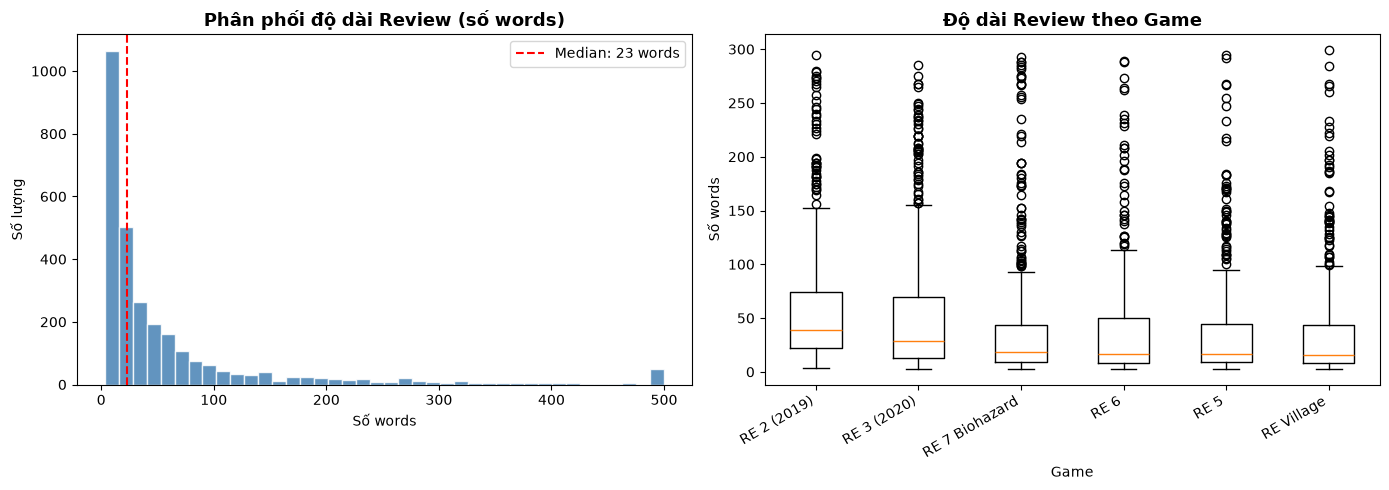

Median review length: 23 words


In [41]:
# ============================================================
# Cell 7 — Review Length Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Length histogram (after cleaning)
axes[0].hist(df['review_length_clean'].clip(upper=500),
             bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Review length distribution (word count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Volume')
axes[0].axvline(df['review_length_clean'].median(), color='red',
                linestyle='--', label=f'Median: {df["review_length_clean"].median():.0f} words')
axes[0].legend()

# Boxplot theo game
game_order = df.groupby('game_name')['review_length_clean'].median().sort_values(ascending=False).index
df_box = df[df['review_length_clean'] <= 300]
axes[1].boxplot(
    [df_box[df_box['game_name'] == g]['review_length_clean'].values for g in game_order],
    tick_labels=[g.replace('Resident Evil ', 'RE ') for g in game_order],
    vert=True
)
axes[1].set_title('Review Length by Game', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Game')
axes[1].set_ylabel('Number of words')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/../notebooks/eda_review_length.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Median review length: {df["review_length_clean"].median():.0f} words')

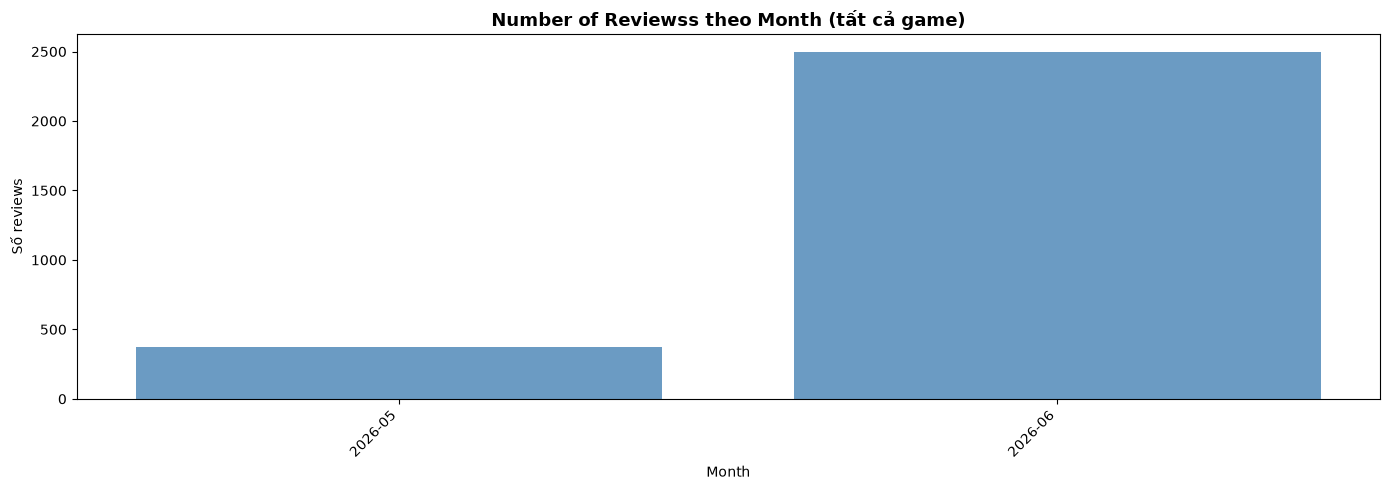

In [42]:
# ============================================================
# Cell 8 — Analysis over time
# ============================================================

# Ensure date_created column is datetime
if 'date_created' not in df.columns:
    df['date_created'] = pd.to_datetime(df['timestamp_created'], unit='s', errors='coerce')
else:
    df['date_created'] = pd.to_datetime(df['date_created'], errors='coerce')

df['year_month'] = df['date_created'].dt.to_period('M')

# Reviews by month
monthly = df.groupby('year_month').size().reset_index(name='count')
monthly['year_month_str'] = monthly['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(monthly)), monthly['count'], color='steelblue', alpha=0.8)
ax.set_xticks(range(0, len(monthly), max(1, len(monthly)//12)))
ax.set_xticklabels(
    monthly['year_month_str'].iloc[::max(1, len(monthly)//12)],
    rotation=45, ha='right'
)
ax.set_title('Number of Reviews by Month (all games)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of reviews')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/../notebooks/eda_reviews_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

In [43]:
# ============================================================
# Cell 9 — Detect Review Bombing
# ============================================================

print('=== Detect Review Bombing ===')
print('Review bombing: Large number of negative reviews in a short time')
print()

df['date_only'] = df['date_created'].dt.date

# Calculate daily reviews for each game
daily_game = df.groupby(['game_name', 'date_only']).agg(
    total_reviews=('review_id', 'count'),
    negative_reviews=('voted_up', lambda x: (x == False).sum()),
    positive_reviews=('voted_up', lambda x: (x == True).sum()),
).reset_index()

daily_game['neg_ratio'] = daily_game['negative_reviews'] / daily_game['total_reviews'].clip(lower=1)

# Threshold: > 20 reviews per day AND > 60% are negative
bombing_threshold_reviews = 20
bombing_threshold_neg_ratio = 0.60

bombing_days = daily_game[
    (daily_game['total_reviews'] >= bombing_threshold_reviews) &
    (daily_game['neg_ratio'] >= bombing_threshold_neg_ratio)
].sort_values('total_reviews', ascending=False)

if bombing_days.empty:
    print('  No significant review bombing detected.')
else:
    print(f'  Detected {len(bombing_days)} days showing review bombing signs:')
    display(bombing_days.head(10))

print()
print('=== Top 10 days with most reviews ===')
top_days = daily_game.nlargest(10, 'total_reviews')[['game_name', 'date_only', 'total_reviews', 'neg_ratio']]
display(top_days)

=== Detect Review Bombing ===
Review bombing: Large number of negative reviews in a short time

  No significant review bombing detected.

=== Top 10 days with most reviews ===


,game_name,date_only,total_reviews,neg_ratio
50,Resident Evil 3 (2020),2026-06-14,33,0.151515
136,Resident Evil 7 Biohazard,2026-06-07,31,0.064516
143,Resident Evil 7 Biohazard,2026-06-14,31,0.032258
12,Resident Evil 2 (2019),2026-06-07,30,0.066667
18,Resident Evil 2 (2019),2026-06-13,27,0.000000
44,Resident Evil 3 (2020),2026-06-08,27,0.222222
142,Resident Evil 7 Biohazard,2026-06-13,27,0.000000
14,Resident Evil 2 (2019),2026-06-09,26,0.076923
17,Resident Evil 2 (2019),2026-06-12,26,0.076923
45,Resident Evil 3 (2020),2026-06-09,26,0.076923


=== Playtime theo Recommendation ===


,count,mean,std,min,25%,50%,75%,max
recommendation,,,,,,,,
Not Recommended,396.0,13.66,13.72,0.2,5.5,10.45,18.32,145.0
Recommended,2478.0,21.17,24.46,0.1,9.6,15.50,25.20,583.5


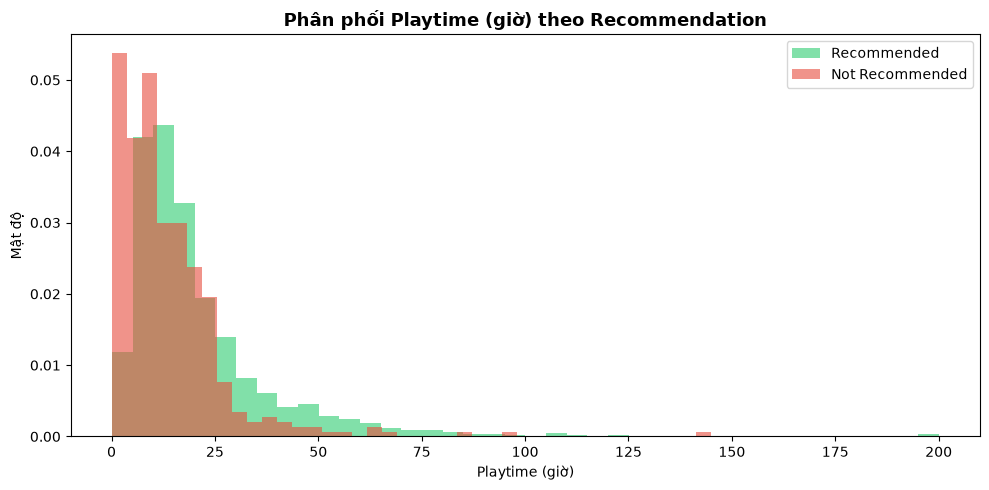

In [44]:
# ============================================================
# Cell 10 — Playtime Analysis
# ============================================================

if 'playtime_hours' not in df.columns:
    df['playtime_hours'] = (df['playtime_forever_mins'] / 60).round(1)
    df['playtime_at_review_hours'] = (df['playtime_at_review_mins'] / 60).round(1)

# Compare playtime between Recommended and Not Recommended
print('=== Playtime theo Recommendation ===')
playtime_stats = df.groupby('recommendation')['playtime_hours'].describe().round(2)
display(playtime_stats)

fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [('Recommended', '#2ecc71'), ('Not Recommended', '#e74c3c')]:
    subset = df[df['recommendation'] == label]['playtime_hours'].clip(upper=200)
    ax.hist(subset, bins=40, alpha=0.6, label=label, color=color, density=True)

ax.set_title('Playtime (hours) Distribution by Recommendation', fontsize=13, fontweight='bold')
ax.set_xlabel('Playtime (hours)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/../notebooks/eda_playtime_dist.png', dpi=120, bbox_inches='tight')
plt.show()

In [45]:
# ============================================================
# Cell 11 — EDA Summary
# ============================================================

print('=== EDA Summary ===')
print(f'  Total reviews (clean)      : {len(df):,}')
print(f'  Number of games                   : {df["game_name"].nunique()}')
print(f'  Recommended ratio         : {(df["voted_up"].sum() / len(df) * 100):.1f}%')
print(f'  Median playtime (hours)     : {df["playtime_hours"].median():.1f}')
print(f'  Median review length      : {df["review_length_clean"].median():.0f} words')
print(f'  Reviews showing bombing signs  : {len(bombing_days)} days')
print(f'  Time range          : {df["date_created"].min().date()} → {df["date_created"].max().date()}')

=== EDA Summary ===
  Total reviews (clean)      : 2,874
  Number of games                   : 6
  Recommended ratio         : 86.2%
  Median playtime (hours)     : 14.8
  Median review length      : 23 words
  Reviews showing bombing signs  : 0 days
  Time range          : 2026-05-26 → 2026-06-25


In [46]:
# ============================================================
# Cell 12 — Save Clean Data
# ============================================================

# Select necessary columns for the next tasks
keep_cols = [
    'appid', 'game_name', 'review_id',
    'review_text', 'review_text_clean', 'review_length_clean',
    'voted_up', 'recommendation',
    'playtime_hours', 'playtime_at_review_hours',
    'votes_up', 'votes_funny', 'weighted_vote_score',
    'date_created', 'year_month', 'steam_purchase', 'early_access_review',
]
keep_cols = [c for c in keep_cols if c in df.columns]
clean_df = df[keep_cols].copy()

clean_path = f'{DATA_DIR}/clean_steam_data.csv'
clean_df.to_csv(clean_path, index=False, encoding='utf-8-sig')

size_kb = os.path.getsize(clean_path) / 1024
print(f'Clean data saved: {clean_path}')
print(f'  Shape    : {clean_df.shape}')
print(f'  Size     : {size_kb:.1f} KB')
print()
print('Task 2 complete! Move to 03_visualization.ipynb')

Clean data saved: ../data/clean_steam_data.csv
  Shape    : (2874, 17)
  Size     : 2391.2 KB

Task 2 complete! Move to 03_visualization.ipynb
